## Effective radius

As the REFF_AERO variable showed little growth after Pinatubo, I'll try to see if there is another way to look at it, or if the modes are better to look at seperately.

In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import cftime
import calendar
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.path as mpath
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.ticker as mticker
from matplotlib.colors import TwoSlopeNorm
from matplotlib.patches import Rectangle
import imageio
import os
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import datetime #import datetime
from glob import glob
from scipy import signal

In [ ]:
# dask
import dask
import dask.array as da
import distributed
from dask.distributed import Client

client = Client()
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 8
Total threads: 32,Total memory: 35.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:35145,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:43839,Total threads: 4
Dashboard: http://127.0.0.1:35959/status,Memory: 4.38 GiB
Nanny: tcp://127.0.0.1:34539,


2025-12-03 19:41:54,519 - distributed.scheduler - WARNING - Removing worker 'tcp://127.0.0.1:43839' caused the cluster to lose already computed task(s), which will be recomputed elsewhere: {('original-open_dataset-NCONC03-bd945a05e243c0d6f8374ba71edd14a5', 0, 0, 0, 0), ('open_dataset-NCONC03-6111955bf1623cf710b5378e7a1c999f', 0, 0, 0, 0)} (stimulus_id='handle-worker-cleanup-1764787314.5188625')
2025-12-03 19:41:54,525 - distributed.nanny - WARNING - Restarting worker
2025-12-03 19:41:59,391 - distributed.nanny - WARNING - Restarting worker
2025-12-03 19:44:15,218 - distributed.nanny - WARNING - Restarting worker
2025-12-03 19:44:30,961 - distributed.nanny - WARNING - Restarting worker
2025-12-03 19:44:32,689 - distributed.nanny - WARNING - Restarting worker
2025-12-03 19:48:41,460 - distributed.nanny - WARNING - Restarting worker
2025-12-03 19:48:41,465 - distributed.nanny - WARNING - Restarting worker
2025-12-03 19:48:41,467 - distributed.nanny - WARNING - Restarting worker
2025-12-03

In [ ]:
#client.close()

In [3]:
path_atm_22 = "/nird/datapeak/NS1004K/elihho/NHIST_tropstratchem_20251125_pinatubo10Tg22_e01/atm/hist"
ds_22 = xr.open_mfdataset(f"{path_atm_22}/NHIST_tropstratchem_f09_tn14_20251125_Pinatubo10Tg22_01.cam.h0.*.nc", combine="by_coords", parallel=True)


In [4]:
path_atm_19_c =  "/nird/datapeak/NS1004K/elihho/NHIST_tropstratchem_20251128_pinatubo10Tg19_e01/atm/hist"
ds_19_c = xr.open_mfdataset(f"{path_atm_19_c}/NHIST_tropstratchem_f09_tn14_20251128_Pinatubo10Tg19_01.cam.h0.*.nc", combine="by_coords", parallel=True)

In [5]:
path_atm_24 = "/nird/datapeak/NS1004K/elihho/NHIST_tropstratchem_20251129_pinatubo17Tg24_e01/atm/hist"
ds_24 = xr.open_mfdataset(f"{path_atm_24}/NHIST_tropstratchem_f09_tn14_20251129_Pinatubo17Tg24_01.cam.h0.*.nc", combine="by_coords", parallel=True)

In [6]:
path_atm = "/nird/datapeak/NS1004K/elihho/NHIST_tropochem_250916/atm/hist"
ds_19 = xr.open_mfdataset(f"{path_atm}/NHIST_tropstratchem_f09_tn14_20250917_1975_2014.cam.h0.199*.nc", combine="by_coords", parallel=True)

In [7]:
def shift_one_month_back(t):
    if t.month == 1:
        return cftime.DatetimeNoLeap(t.year - 1, 12, t.day, t.hour, t.minute, t.second)
    else:
        return cftime.DatetimeNoLeap(t.year, t.month - 1, t.day, t.hour, t.minute, t.second)

shifted_time = np.array([shift_one_month_back(t) for t in ds_19['time'].values])
ds_19 = ds_19.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_22['time'].values])
ds_22 = ds_22.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_19_c['time'].values])
ds_19_c = ds_19_c.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_24['time'].values])
ds_24 = ds_24.assign_coords(time=shifted_time)

In [8]:
lat_19 = ds_19["lat"]
weighted_lat_19 = np.cos(np.deg2rad(lat_19))
lat_19_c = ds_19_c["lat"]
weighted_lat_19_c = np.cos(np.deg2rad(lat_19_c))
lat_22 = ds_22["lat"]
weighted_lat_22 = np.cos(np.deg2rad(lat_22))
lat_24 = ds_24["lat"]
weighted_lat_24 = np.cos(np.deg2rad(lat_24))


In [9]:
tropopause_19 = ds_19["TROP_P"].weighted(weighted_lat_19).mean(dim=["lat", "lon"])
p_lev_19 = tropopause_19 * 0.01
tropopause_19_c = ds_19_c["TROP_P"].weighted(weighted_lat_19_c).mean(dim=["lat", "lon"])
p_lev_19_c = tropopause_19_c * 0.01
tropopause_22 = ds_22["TROP_P"].weighted(weighted_lat_22).mean(dim=["lat", "lon"])
p_lev_22 = tropopause_22 * 0.01
tropopause_24 = ds_24["TROP_P"].weighted(weighted_lat_24).mean(dim=["lat", "lon"])
p_lev_24 = tropopause_24 * 0.01

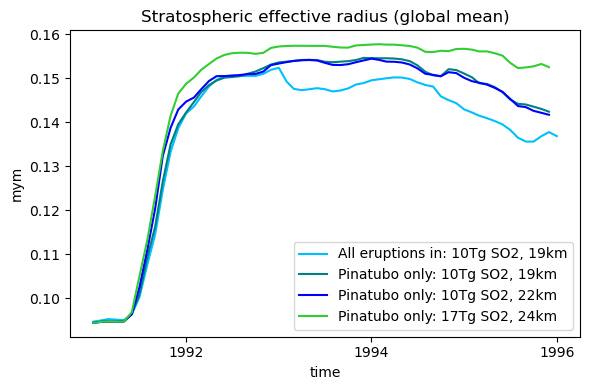

In [21]:
cm_to_mym = 10000
p_lev = 20

SReff = ds_19["REFF_AERO"].sel(lev = p_lev, method = "nearest")
SReff = SReff.weighted(weighted_lat_19).mean(dim=["lat", "lon"])*cm_to_mym
SReff = SReff.sel(time=slice("1991-01-01", "1996-01-01"))

SReff_19_c = ds_19_c["REFF_AERO"].sel(lev = p_lev, method = "nearest")
SReff_19_c = SReff_19_c.weighted(weighted_lat_19_c).mean(dim=["lat", "lon"])*cm_to_mym

SReff_22 = ds_22["REFF_AERO"].sel(lev = p_lev, method="nearest")
SReff_22 = SReff_22.weighted(weighted_lat_22).mean(dim=["lat", "lon"])*cm_to_mym

SReff_24 = ds_24["REFF_AERO"].sel(lev = p_lev, method="nearest")
SReff_24 = SReff_24.weighted(weighted_lat_24).mean(dim=["lat", "lon"])*cm_to_mym

plt.figure(figsize=(6, 4))
SReff.plot(color = "deepskyblue", label = "All eruptions in: 10Tg SO2, 19km")
SReff_19_c.plot(color = "teal", label = "Pinatubo only: 10Tg SO2, 19km")
SReff_22.plot(color = "blue", label = "Pinatubo only: 10Tg SO2, 22km")
SReff_24.plot(color = "limegreen", label = "Pinatubo only: 17Tg SO2, 24km")
plt.ylabel("mym")
plt.title("Stratospheric effective radius (global mean)")
plt.legend()
plt.tight_layout()

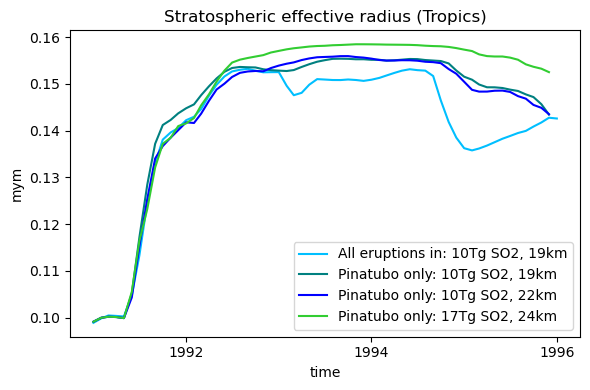

In [92]:
cm_to_mym = 10000
p_lev = 20

SReff = ds_19["REFF_AERO"].sel(lev = p_lev, method = "nearest")
SReff = SReff.sel(lat = slice(-20,20))
SReff = SReff.weighted(weighted_lat_19).mean(dim=["lat", "lon"])*cm_to_mym
SReff = SReff.sel(time=slice("1991-01-01", "1996-01-01"))

SReff_19_c = ds_19_c["REFF_AERO"].sel(lev = p_lev, method = "nearest")
SReff_19_c = SReff_19_c.sel(lat = slice(-20,20))
SReff_19_c = SReff_19_c.weighted(weighted_lat_19_c).mean(dim=["lat", "lon"])*cm_to_mym

SReff_22 = ds_22["REFF_AERO"].sel(lev = p_lev, method="nearest")
SReff_22 = SReff_22.sel(lat = slice(-20,20))
SReff_22 = SReff_22.weighted(weighted_lat_22).mean(dim=["lat", "lon"])*cm_to_mym

SReff_24 = ds_24["REFF_AERO"].sel(lev = p_lev, method="nearest")
SReff_24 = SReff_24.sel(lat = slice(-20,20))
SReff_24 = SReff_24.weighted(weighted_lat_24).mean(dim=["lat", "lon"])*cm_to_mym

plt.figure(figsize=(6, 4))
SReff.plot(color = "deepskyblue", label = "All eruptions in: 10Tg SO2, 19km")
SReff_19_c.plot(color = "teal", label = "Pinatubo only: 10Tg SO2, 19km")
SReff_22.plot(color = "blue", label = "Pinatubo only: 10Tg SO2, 22km")
SReff_24.plot(color = "limegreen", label = "Pinatubo only: 17Tg SO2, 24km")
plt.ylabel("mym")
plt.title("Stratospheric effective radius (Tropics)")
plt.legend()
plt.tight_layout()


In [56]:
p0 = ds_19["P0"]  
PS = ds_19["PS"]             
hyai = ds_19["hyai"]
hybi = ds_19["hybi"]
g = 9.81

p_edges = hyai * p0 + hybi * PS
p_mid = 0.5 * (p_edges.isel(ilev=slice(1,None)) + p_edges.isel(ilev=slice(0,-1)))
dp = p_edges.isel(ilev=slice(0,-1)) - p_edges.isel(ilev=slice(1,None))
dm = dp / g


In [58]:
p_mid_hpa = p_mid / 100.0
mask = (p_mid_hpa >= 20) & (p_mid_hpa <= 50)

SReff_selected = ds_19["REFF_AERO"].isel(lev=mask)
dm_selected = (p_edges.isel(ilev=slice(0,-1)) - p_edges.isel(ilev=slice(1,None))).isel(ilev=mask) / g
SReff_weighted = (SReff_selected * dm_selected).weighted(weighted_lat_19).mean(dim=["lat","lon","lev"])
SReff_weighted = SReff_weighted * cm_to_mym

SReff_weighted.plot(color="deepskyblue", label="All eruptions: 10Tg SO2, 19km")

IndexError: Boolean array size 120 is used to index array with shape (32,).

In [ ]:
SReff = ds_19["REFF_AERO"].sel(lev = slice(50,20), method = "nearest")
SReff = SReff.sel(lat = slice(-20,20))
SReff = SReff.weighted(weighted_lat_19).mean(dim=["lat", "lon"])*cm_to_mym
SReff_weighted = (SReff * dp).sum("lev") /dm.sum("lev")
SReff = SReff.sel(time=slice("1991-01-01", "1996-01-01"))

SReff_19_c = ds_19_c["REFF_AERO"].sel(lev = slice(50,20), method = "nearest")
SReff_19_c = SReff_19_c.sel(lat = slice(-20,20))
SReff_19_c = SReff_19_c.weighted(weighted_lat_19_c).mean(dim=["lat", "lon"])*cm_to_mym

SReff_22 = ds_22["REFF_AERO"].sel(lev = slice(50,20), method="nearest")
SReff_22 = SReff_22.sel(lat = slice(-20,20))
SReff_22 = SReff_22.weighted(weighted_lat_22).mean(dim=["lat", "lon"])*cm_to_mym

SReff_24 = ds_24["REFF_AERO"].sel(lev = slice(50,20), method="nearest")
SReff_24 = SReff_24.sel(lat = slice(-20,20))
SReff_24 = SReff_24.weighted(weighted_lat_24).mean(dim=["lat", "lon"])*cm_to_mym

plt.figure(figsize=(6, 4))
SReff.plot(color = "deepskyblue", label = "All eruptions in: 10Tg SO2, 19km")
SReff_19_c.plot(color = "teal", label = "Pinatubo only: 10Tg SO2, 19km")
SReff_22.plot(color = "blue", label = "Pinatubo only: 10Tg SO2, 22km")
SReff_24.plot(color = "limegreen", label = "Pinatubo only: 17Tg SO2, 24km")
plt.ylabel("mym")
plt.title("Stratospheric effective radius (Tropics)")
plt.legend()
plt.tight_layout()

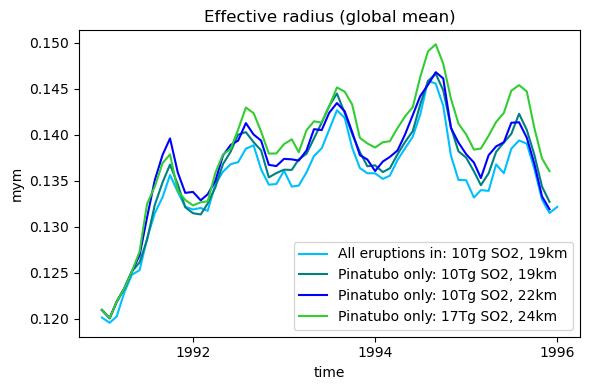

In [11]:
Reff = ds_19["REFF_AERO"].weighted(weighted_lat_19).mean(dim=["lat", "lon", "lev"])*cm_to_mym
Reff = Reff.sel(time=slice("1991-01-01", "1996-01-01"))


Reff_19_c = ds_19_c["REFF_AERO"].weighted(weighted_lat_19_c).mean(dim=["lat", "lon", "lev"])*cm_to_mym

Reff_22 = ds_22["REFF_AERO"].weighted(weighted_lat_22).mean(dim=["lat", "lon", "lev"])*cm_to_mym

Reff_24 = ds_24["REFF_AERO"].weighted(weighted_lat_24).mean(dim=["lat", "lon", "lev"])*cm_to_mym

plt.figure(figsize=(6, 4))
Reff.plot(color = "deepskyblue", label = "All eruptions in: 10Tg SO2, 19km")
Reff_19_c.plot(color = "teal", label = "Pinatubo only: 10Tg SO2, 19km")
Reff_22.plot(color = "blue", label = "Pinatubo only: 10Tg SO2, 22km")
Reff_24.plot(color = "limegreen", label = "Pinatubo only: 17Tg SO2, 24km")
plt.ylabel("mym")
plt.title("Effective radius (global mean)")
plt.legend()
plt.tight_layout()

2025-12-03 19:54:53,527 - distributed.worker - ERROR - Worker stream died during communication: tcp://127.0.0.1:44749
Traceback (most recent call last):
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/tornado/iostream.py", line 861, in _read_to_buffer
    bytes_read = self.read_from_fd(buf)
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/tornado/iostream.py", line 1113, in read_from_fd
    return self.socket.recv_into(buf, len(buf))
           ~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^
ConnectionResetError: [Errno 104] Connection reset by peer

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/distributed/worker.py", line 2073, in gather_dep
    response = await get_data_from_worker(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^
        rpc=self.rpc, keys=to_gather, worker=worker, who=self.address
       

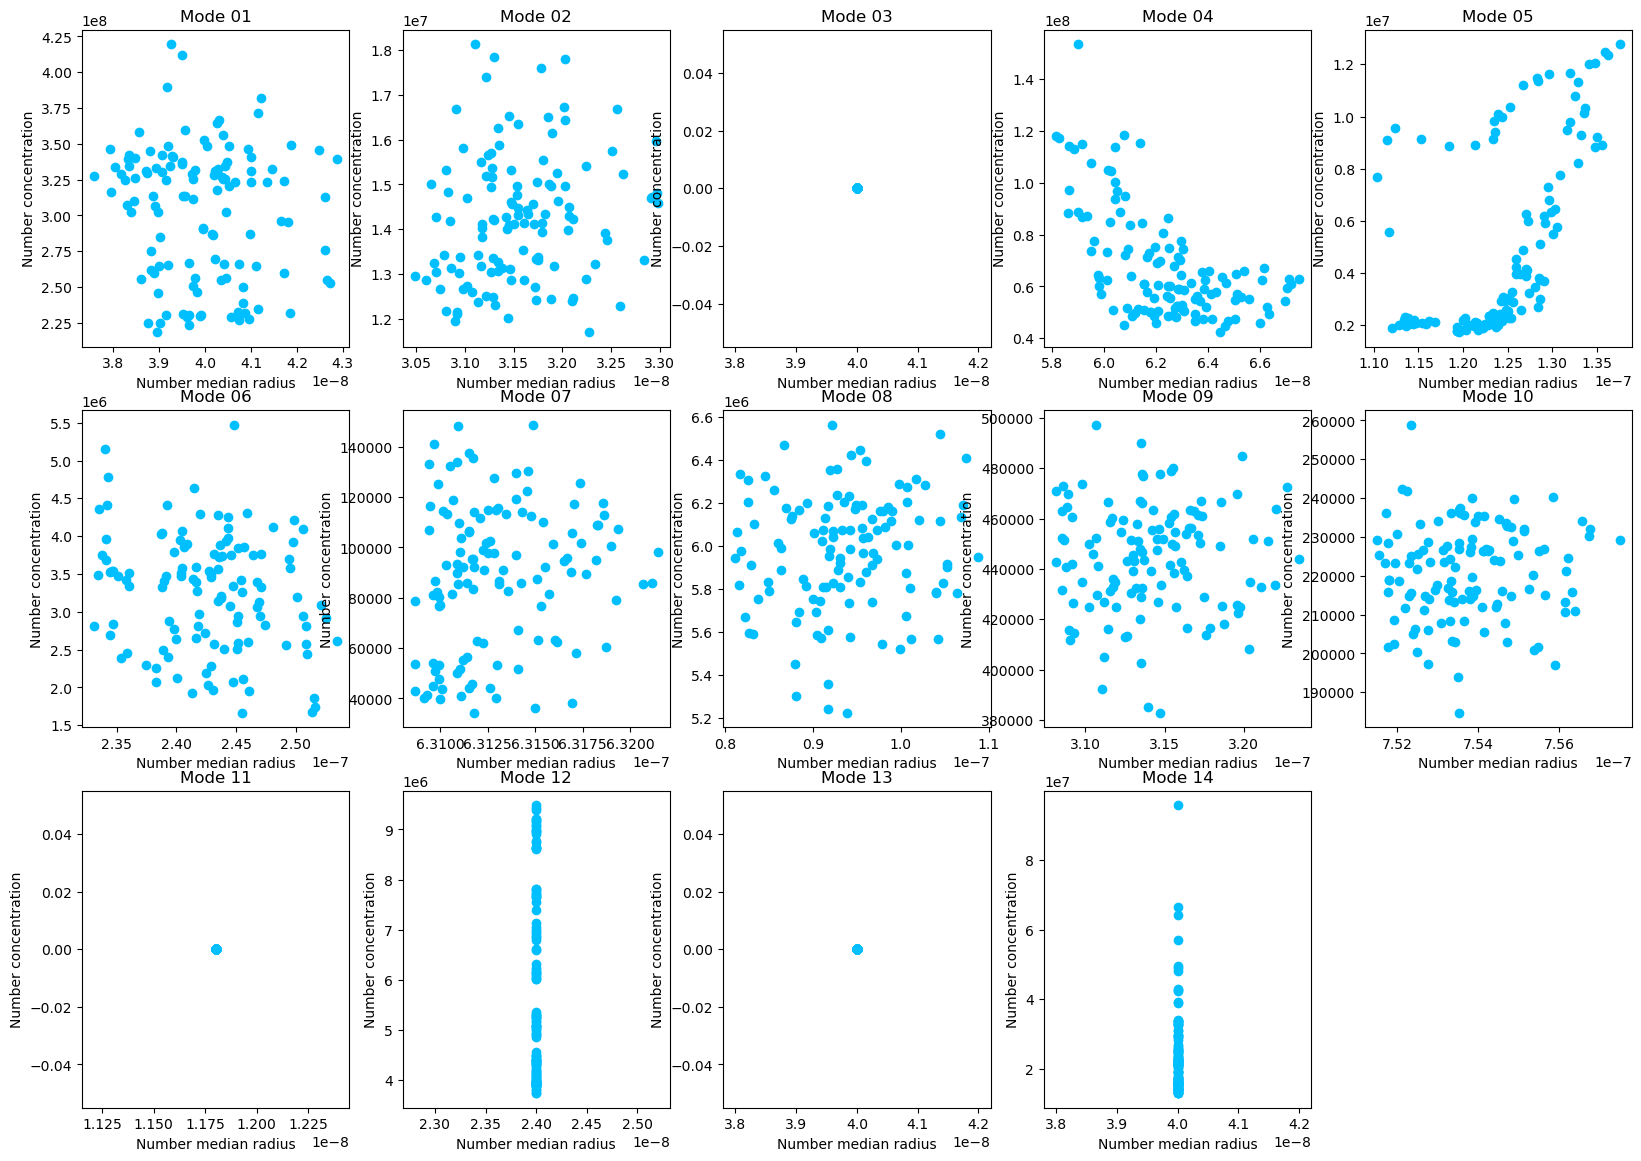

In [90]:
# vars to use: NMR, SIGMA, NCONC, VCONC, NNAT_
mode_list = ["01", "02", "03", "04", "05", "06", "07", "08", "09", "10", "11", "12", "13", "14"]

fig, axes = plt.subplots(3, 5, figsize=(20, 14), sharex=False, sharey=False)
axes = axes.flatten() 
for i, mode in enumerate(mode_list):
    nmr_var = f"NMR{mode}"
    nconc_var = f"NCONC{mode}"
    
    nmr = ds_19[nmr_var].weighted(weighted_lat_19).mean(dim=["lat","lon","lev"])
    nconc = ds_19[nconc_var].weighted(weighted_lat_19).mean(dim=["lat","lon","lev"])
    
    axes[i].scatter(nmr, nconc, color="deepskyblue")
    axes[i].set_xlabel("Number median radius")
    axes[i].set_ylabel("Number concentration")
    axes[i].set_title(f"Mode {mode}")

for j in range(i+1, 3*5):
    fig.delaxes(axes[j])

plt.show()

In [13]:
ds_19["NCONC01"]

<xarray.DataArray 'NCONC01' (time: 120, lev: 32, lat: 192, lon: 288)> Size: 849MB
dask.array<concatenate, shape=(120, 32, 192, 288), dtype=float32, chunksize=(1, 32, 192, 288), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon      (lon) float64 2kB 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.2 357.5 358.8
  * lev      (lev) float64 256B 3.643 7.595 14.36 24.61 ... 957.5 976.3 992.6
  * time     (time) object 960B 1990-01-01 00:00:00 ... 1999-12-01 00:00:00
Attributes:
    mdims:         1
    units:         #/m3
    long_name:     number concentration mode 01
    cell_methods:  time: mean